In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("phamluhuynhmai/classroom-student-behaviors")

print("Downloaded to:", path)

Downloaded to: /kaggle/input/datasets/phamluhuynhmai/classroom-student-behaviors


In [3]:
# # Target folder in Drive
# target_folder = "/content/drive/MyDrive/Faizan  Bahi"

# # Create folder if not exists
# os.makedirs(target_folder, exist_ok=True)

# # Move dataset files
# shutil.move(path, target_folder)

# print("Dataset moved to:", target_folder)

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [3]:
import os
os.environ["PYTHONNOUSERSITE"] = "1"

# ثم نثبت numpy < 2
# !pip install -U "numpy<2" "scipy<1.14" "matplotlib<3.9" "seaborn" "scikit-learn<1.5" "torch" "torchvision" "deepface"

In [4]:
import os

dataset_path = "/kaggle/input/datasets/phamluhuynhmai/classroom-student-behaviors/Behaviors_Features"

print(os.listdir(dataset_path))

['Thong Ke Data.txt', 'Turning_Around', 'Looking_Forward', 'Standing', 'Behaviors Data Version 1.xlsx', 'Reading', 'Raising_Hand', 'Writting', 'Sleeping']


In [5]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 38.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.7 MB/s eta 0:00:00


In [6]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from deepface import DeepFace
from tqdm import tqdm

2026-03-17 08:39:07.569325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773736747.832935      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773736747.909345      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773736748.557063      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773736748.557127      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773736748.557130      55 computation_placer.cc:177] computation placer alr

26-03-17 08:39:30 - Directory /root/.deepface has been created
26-03-17 08:39:30 - Directory /root/.deepface/weights has been created


In [7]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [9]:
labels = ['Turning_Around','Looking_Forward','Standing','Reading','Raising_Hand','Writting','Sleeping']

dataset_dir = "/kaggle/input/datasets/phamluhuynhmai/classroom-student-behaviors/Behaviors_Features"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load Dataset

In [10]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Torchvision (useful if you later work with images)
import torchvision
import torchvision.transforms as transforms

# Data utilities
from torch.utils.data import DataLoader, TensorDataset

# Numerical processing
import numpy as np

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization (optional but useful)
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar for training
from tqdm import tqdm

In [11]:
images_paths = {}
for label in labels:
    images_paths[label] = []
    label_dir = os.path.join(dataset_dir, label)
    if not os.path.exists(label_dir):
        print(f"Warning: {label_dir} not found!")
        continue
    for root, _, files in os.walk(label_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                images_paths[label].append(os.path.join(root, file))



# Show count
for label in labels:
    print(label, len(images_paths[label]))

Turning_Around 46936
Looking_Forward 21269
Standing 7931
Reading 49799
Raising_Hand 16845
Writting 49046
Sleeping 60397


In [12]:
images_paths_balanced = {}
for label, paths in images_paths.items():
    sampled = random.sample(paths, min(6000, len(paths)))
    images_paths_balanced[label] = sampled
    print(f"{label}: {len(sampled)} images")

Turning_Around: 6000 images
Looking_Forward: 6000 images
Standing: 6000 images
Reading: 6000 images
Raising_Hand: 6000 images
Writting: 6000 images
Sleeping: 6000 images


flatten

In [13]:
all_images = []
all_labels = []

for label in labels:
    all_images.extend(images_paths_balanced[label])
    all_labels.extend([label] * len(images_paths_balanced[label]))

label_to_int = {label: i for i, label in enumerate(labels)}
all_labels_int = [label_to_int[label] for label in all_labels]
print(label_to_int)

{'Turning_Around': 0, 'Looking_Forward': 1, 'Standing': 2, 'Reading': 3, 'Raising_Hand': 4, 'Writting': 5, 'Sleeping': 6}


In [14]:
train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels_int,
    test_size=0.2,
    stratify=all_labels_int,
    random_state=42
)

# from sklearn.model_selection import train_test_split

# # Step 1: take only 25% of the data
# images_25, _, labels_25, _ = train_test_split(
#     all_images,
#     all_labels_int,
#     train_size=0.25,
#     stratify=all_labels_int,
#     random_state=42
# )

# # Step 2: split that 25% into train and test
# train_images, test_images, train_labels, test_labels = train_test_split(
#     images_25,
#     labels_25,
#     test_size=0.25,
#     stratify=labels_25,
#     random_state=42
# )

## Feature Extraction

In [15]:
# def extract_features(image_paths):
#     features = []
#     for img_path in tqdm(image_paths, desc="Extracting Features"):
#         try:
#             feature = DeepFace.represent(img_path, model_name="Facenet", enforce_detection=False)
#             features.append(feature[0]["embedding"])
#         except Exception as e:
#             print(f"Error processing {img_path}: {e}")
#             features.append(None)
#     return np.array([f for f in features if f is not None])
def extract_features(image_paths):
    features = []
    valid_labels = []  # to handle failed extractions
    for img_path, label in tqdm(zip(image_paths, train_labels if image_paths is train_images else test_labels),
                                total=len(image_paths),
                                desc="Extracting Features"):
        try:
            reps = DeepFace.represent(img_path, model_name="Facenet", enforce_detection=False)
            features.append(reps[0]["embedding"])
            valid_labels.append(label)
        except Exception as e:
            print(f"Skipping {img_path}: {e}")
    return np.array(features), np.array(valid_labels)

## save embeddings

In [16]:
print("\nExtracting TRAIN features")
train_features, train_labels = extract_features(train_images)

print("\nExtracting TEST features")
test_features, test_labels = extract_features(test_images)

# Define the target directory
save_dir = "/content/drive/MyDrive/Faizan Bahi"
# os.makedirs(save_dir, exist_ok=True)

# Save for reuse (optional)
# np.save(os.path.join(save_dir, "train_features1.npy"), train_features)
# np.save(os.path.join(save_dir, "test_features1.npy"), test_features)
# np.save(os.path.join(save_dir, "train_labels1.npy"), train_labels)
# np.save(os.path.join(save_dir, "test_labels1.npy"), test_labels)



Extracting TRAIN features


Extracting Features:   0%|          | 0/33600 [00:00<?, ?it/s]2026-03-17 08:49:25.583234: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5


26-03-17 08:49:28 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...



  0%|          | 0.00/92.2M [00:00<?, ?B/s]
 15%|█▌        | 14.2M/92.2M [00:00<00:00, 141MB/s]
 53%|█████▎    | 49.3M/92.2M [00:00<00:00, 263MB/s]
100%|██████████| 92.2M/92.2M [00:00<00:00, 245MB/s]
Extracting Features: 100%|██████████| 33600/33600 [3:11:30<00:00,  2.92it/s]  



Extracting TEST features


Extracting Features: 100%|██████████| 8400/8400 [48:40<00:00,  2.88it/s]


In [18]:
# print("\nLoading TRAIN features")
# train_features = np.load(os.path.join(save_dir, "train_features.npy"))
# train_labels = np.load(os.path.join(save_dir, "train_labels.npy"))

# print("\nLoading TEST features")
# test_features = np.load(os.path.join(save_dir, "test_features.npy"))
# test_labels = np.load(os.path.join(save_dir, "test_labels.npy"))
# print(f"Embeddings saved to: {save_dir}")


Loading TRAIN features

Loading TEST features
Embeddings saved to: /content/drive/MyDrive/Faizan Bahi


In [17]:
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

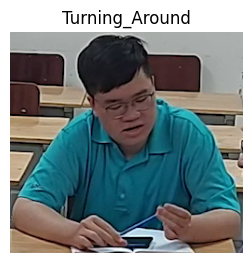

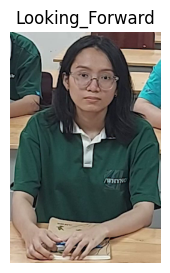

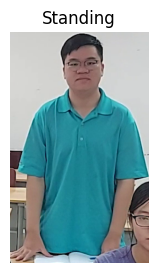

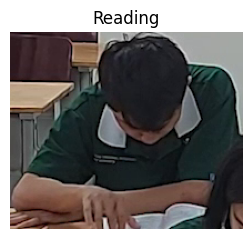

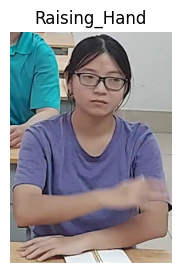

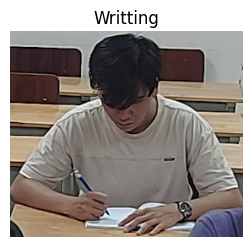

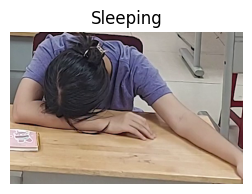

In [18]:
import cv2
import matplotlib.pyplot as plt
import random

for label in labels:
    sample = random.choice(images_paths_balanced[label])
    img = cv2.imread(sample)
    plt.figure(figsize=(3,3))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis("off")
    plt.show()

## pytorch Dataset

In [20]:
X_train = torch.tensor(train_features, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)
X_test = torch.tensor(test_features, dtype=torch.float32)
y_test = torch.tensor(test_labels, dtype=torch.long)

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

## Model

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

In [25]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, h, w = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

In [27]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )

    def forward(self, x):
        b, c, h, w = x.size()

        avg = F.adaptive_avg_pool2d(x, 1).view(b, c)
        maxp = F.adaptive_max_pool2d(x, 1).view(b, c)

        attn = torch.sigmoid(self.mlp(avg) + self.mlp(maxp))
        return x * attn.view(b, c, 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxp, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg, maxp], dim=1)
        attn = torch.sigmoid(self.conv(x_cat))
        return x * attn


class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

In [28]:
class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

In [31]:
class FeatureTransformerModel(nn.Module):

    def __init__(self, input_dim=128, num_classes=7):
        super().__init__()

        self.feature_proj = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.attn_pool = AttentionPooling(256)

        self.classifier = nn.Sequential(
            nn.Linear(256,128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):

        x = self.feature_proj(x)

        x = x.unsqueeze(1)

        x = self.transformer(x)

        x = self.attn_pool(x)

        x = self.classifier(x)

        return x

In [32]:
model = FeatureTransformerModel()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model loaded on:", device)

Model loaded on: cpu


In [35]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# model = BehaviorClassifier(input_dim=128, num_classes=7).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

## training

In [36]:
train_losses = []
val_accuracies = []
best_val_acc = 0
patience_counter = 0
best_weights = None
patience = 10

In [37]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Epoch [1/50]  Loss: 0.7967  Val Acc: 0.9276
Epoch [2/50]  Loss: 0.6221  Val Acc: 0.9515
Epoch [3/50]  Loss: 0.5800  Val Acc: 0.9686
Epoch [4/50]  Loss: 0.5590  Val Acc: 0.9632
Epoch [5/50]  Loss: 0.5447  Val Acc: 0.9715
Epoch [6/50]  Loss: 0.5342  Val Acc: 0.9749
Epoch [7/50]  Loss: 0.5251  Val Acc: 0.9735
Epoch [8/50]  Loss: 0.5207  Val Acc: 0.9755
Epoch [9/50]  Loss: 0.5143  Val Acc: 0.9794
Epoch [10/50]  Loss: 0.5104  Val Acc: 0.9825
Epoch [11/50]  Loss: 0.5055  Val Acc: 0.9817
Epoch [12/50]  Loss: 0.5041  Val Acc: 0.9805
Epoch [13/50]  Loss: 0.4978  Val Acc: 0.9832
Epoch [14/50]  Loss: 0.4959  Val Acc: 0.9821
Epoch [15/50]  Loss: 0.4941  Val Acc: 0.9799
Epoch [16/50]  Loss: 0.4906  Val Acc: 0.9838
Epoch [17/50]  Loss: 0.4889  Val Acc: 0.9808
Epoch [18/50]  Loss: 0.4862  Val Acc: 0.9848
Epoch [19/50]  Loss: 0.4847  Val Acc: 0.9864
Epoch [20/50]  Loss: 0.4832  Val Acc: 0.9862
Epoch [21/50]  Loss: 0.4769  Val Acc: 0.9850
Epoch [22/50]  Loss: 0.4783  Val Acc: 0.9862
Epoch [23/50]  Loss

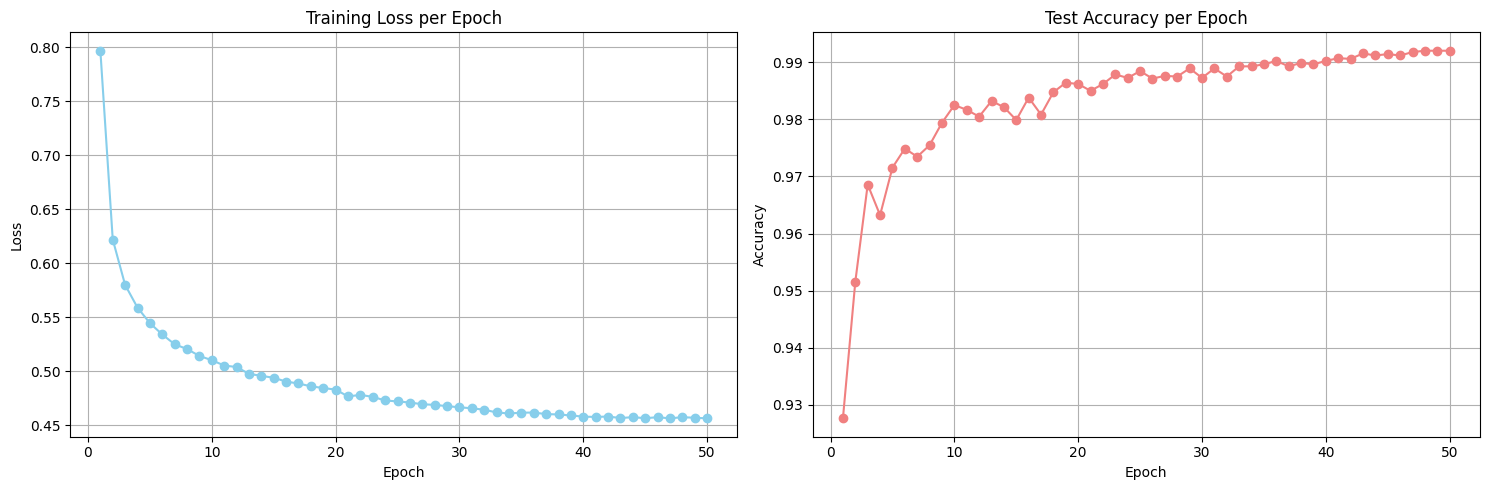

In [38]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Training Loss
ax1.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle='-', color='skyblue')
ax1.set_title('Training Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Plot Test Accuracy
ax2.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', linestyle='-', color='lightcoral')
ax2.set_title('Test Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [39]:
model.load_state_dict(best_weights)
torch.save(model.state_dict(), "student_behavior_classifier_pytorch.pth")
print(f" Best model saved! Best Test Accuracy: {best_val_acc:.4f}")


 Best model saved! Best Test Accuracy: 0.9920


### Evaluation

In [40]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y_true = y.cpu().numpy()
        outputs = model(x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(y_true)

all_preds = np.array(all_preds)
all_true = np.array(all_true)
print(classification_report(test_labels, all_preds, target_names=labels))

                 precision    recall  f1-score   support

 Turning_Around       0.99      0.98      0.99      1200
Looking_Forward       1.00      1.00      1.00      1200
       Standing       0.99      1.00      0.99      1200
        Reading       1.00      1.00      1.00      1200
   Raising_Hand       0.99      0.99      0.99      1200
       Writting       1.00      1.00      1.00      1200
       Sleeping       0.99      0.98      0.99      1200

       accuracy                           0.99      8400
      macro avg       0.99      0.99      0.99      8400
   weighted avg       0.99      0.99      0.99      8400



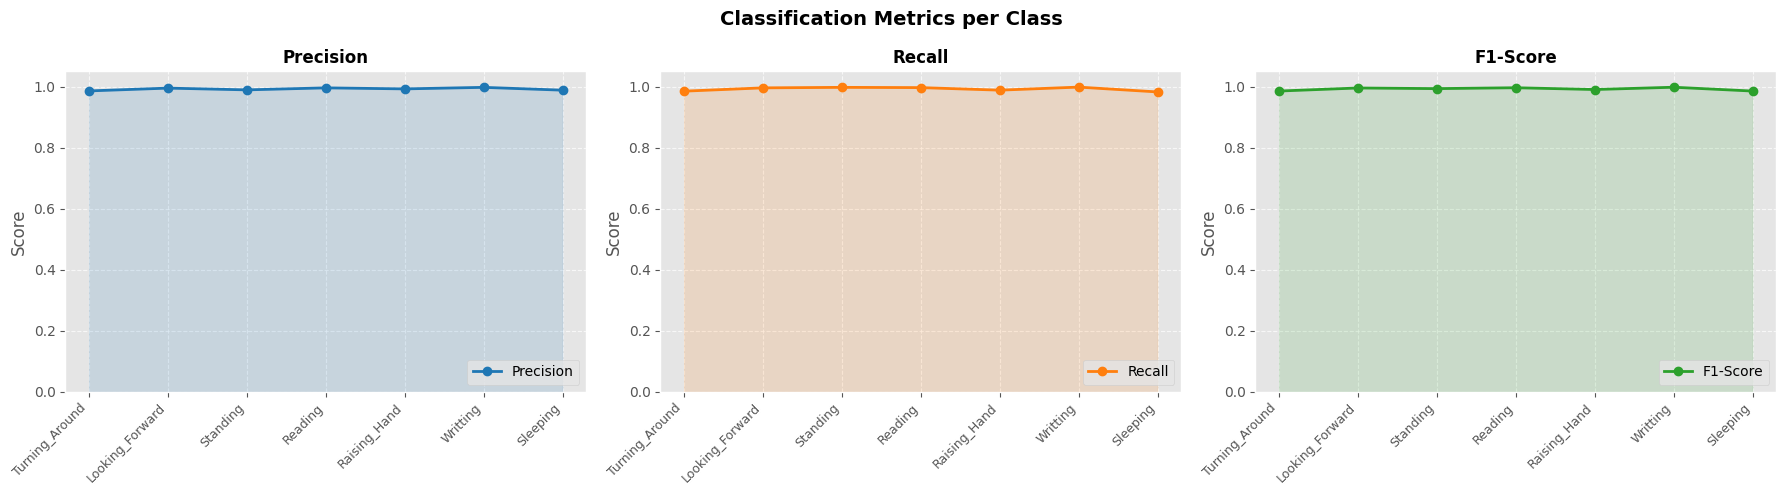

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y_true = y.cpu().numpy()
        outputs = model(x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(y_true)

all_preds = np.array(all_preds)
all_true = np.array(all_true)

report = classification_report(test_labels, all_preds, target_names=labels, output_dict=True)

precision = [report[label]['precision'] for label in labels]
recall    = [report[label]['recall']    for label in labels]
f1        = [report[label]['f1-score']  for label in labels]

# livelossplot-style: side-by-side line plots with markers
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Classification Metrics per Class', fontsize=14, fontweight='bold')

x = np.arange(len(labels))
plots = [
    ('Precision', precision, '#1f77b4'),
    ('Recall',    recall,    '#ff7f0e'),
    ('F1-Score',  f1,        '#2ca02c'),
]

for ax, (title, values, color) in zip(axes, plots):
    ax.plot(x, values, marker='o', color=color, linewidth=2, markersize=6, label=title)
    ax.fill_between(x, values, alpha=0.15, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

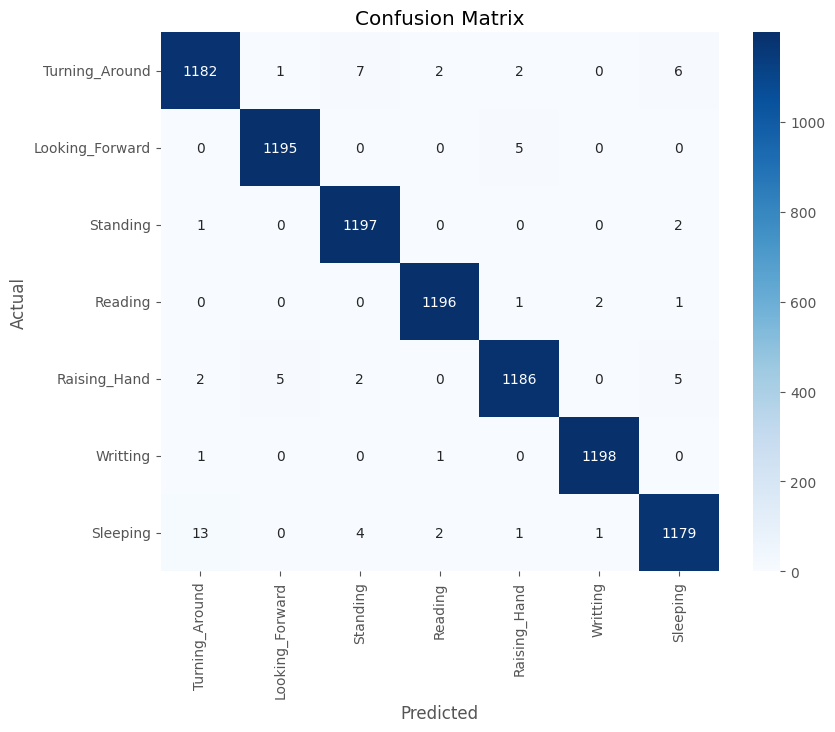

In [42]:
cm = confusion_matrix(test_labels, all_preds)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [48]:
# num_samples = 2

# max_len = min(len(test_images), len(test_labels), len(all_preds))
# indices = random.sample(range(max_len), min(num_samples, max_len))

# plt.figure(figsize=(16, 10))

# for i, idx in enumerate(indices):
#     img_path = test_images[idx]

#     true_label = labels[int(test_labels[idx])]   # ground truth from original split
#     pred_label = labels[int(all_preds[idx])]      # model prediction
#     is_correct = (int(test_labels[idx]) == int(all_preds[idx]))

#     img = cv2.imread(img_path)
#     if img is None:
#         continue

#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#     plt.subplot(3, 4, i + 1)
#     plt.imshow(img_rgb)

#     color = 'green' if is_correct else 'red'
#     status = "✓ Correct" if is_correct else "✗ Wrong"
#     plt.title(
#         f"True:  {true_label}\nPred: {pred_label}\n{status}",
#         fontsize=9,
#         color=color,
#         fontweight='bold'
#     )
#     plt.axis("off")

# plt.tight_layout()
# plt.suptitle("Test Data Results", y=1.02, fontsize=14)
# plt.show()